# Faster RCNN as Neuro component and teacher for SODT

## Setup


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from torch.optim import SGD
from torch.utils.data import DataLoader

from notebooks.util import resolve_root
from neuro.config import NeuroConfig, NeuroTrainConfig
from neuro.faster_rcnn import NeuroFasterRCNN
from neuro.prepare_dataset import PCBDataset
from neuro.preprocess_dataset import (
    RCNNPreprocessing,
    test_preprocess,
    train_preprocess,
    visualize_preprocessing,
    visualize_rcnn_preprocessing,
)
from neuro.train import evaluate_model, train_model
from neuro.utils import (
    detection_collate_fn,
)
from util.config import load_yaml
from util.artifacts import next_run_artifacts
from util.device import select_device
from util.io import save_json
from util.seed import seed_everything

resolve_root()

train_config = load_yaml("neuro_train.yaml", NeuroTrainConfig)
neuro_config = load_yaml("neuro.yaml", NeuroConfig)

seed_everything(
    seed=train_config["seed"],
    deterministic=train_config["deterministic"],
)

device = select_device(train_config["device"])
class_names = train_config["dataset"]["class_names"]
device, class_names

(device(type='cuda'),
 ['open', 'short', 'mouse_bite', 'spur', 'pinhole', 'spurious_copper'])

## Dataset Preparation and Inspection


========== Inspect trainval.txt ==========
DeepPCB dataset inspection
Files: 1,000
Configured classes: 6
Classes present in annotations: 6
Empty images: 0
Total defect boxes: 6,873
Defect boxes per image: min 1, mean 6.87, max 15


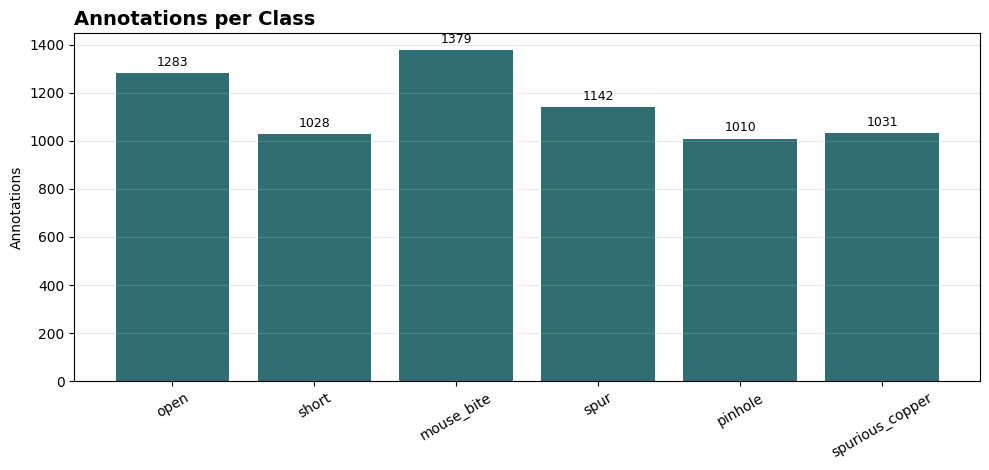

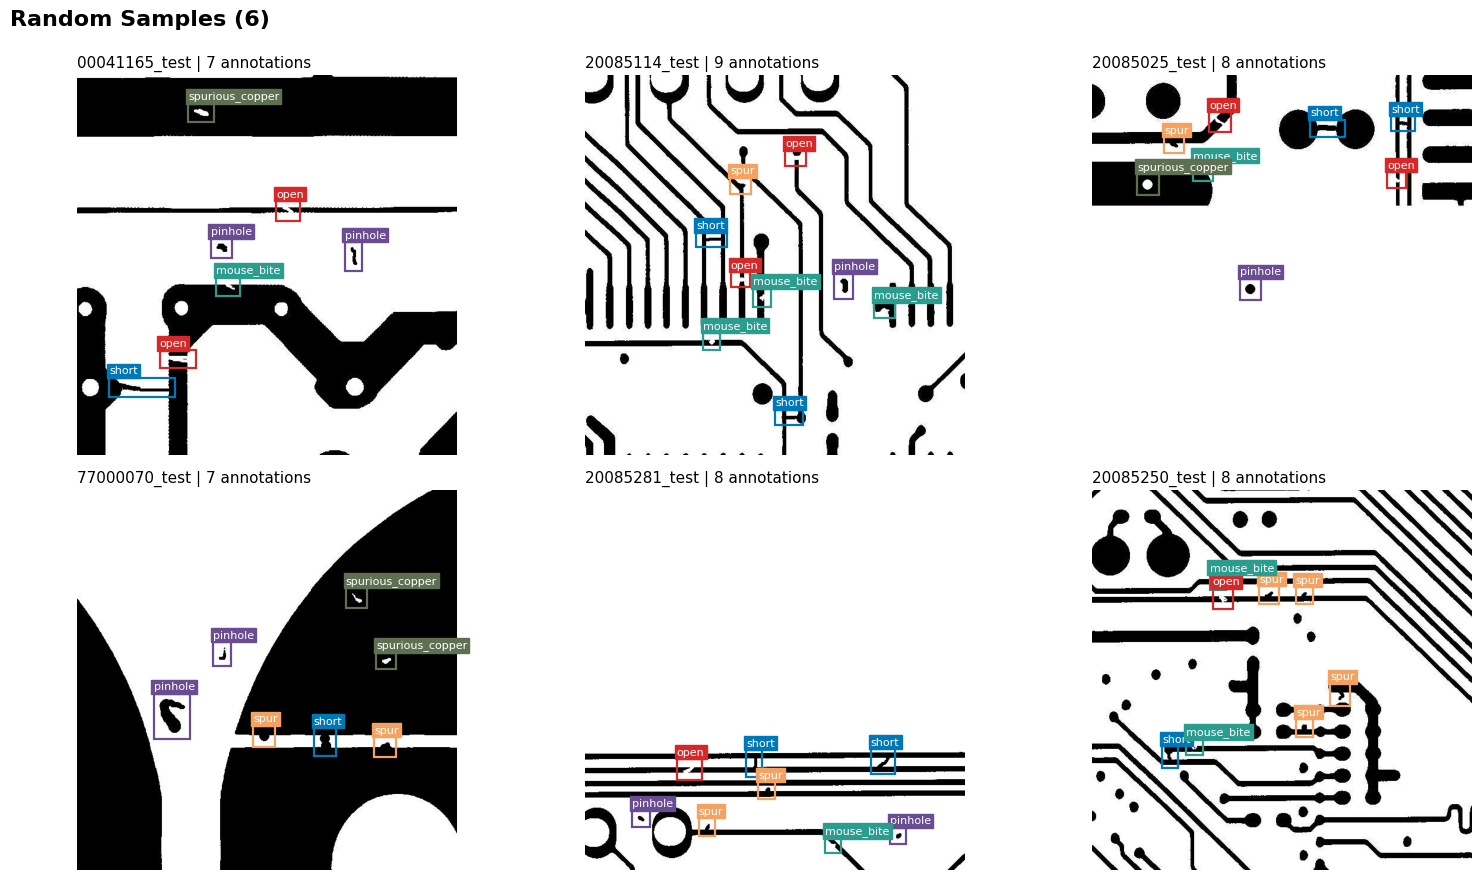

========== Inspect test.txt ==========
DeepPCB dataset inspection
Files: 500
Configured classes: 6
Classes present in annotations: 6
Empty images: 0
Total defect boxes: 3,140
Defect boxes per image: min 2, mean 6.28, max 13


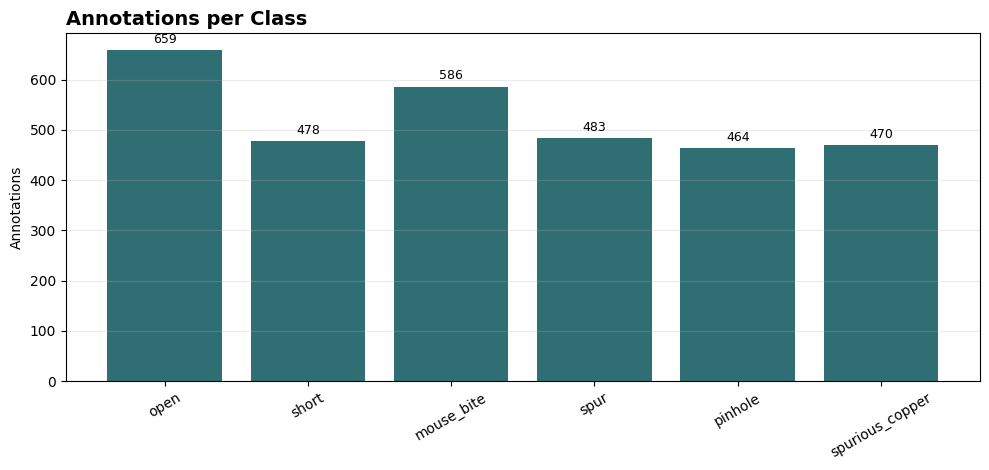

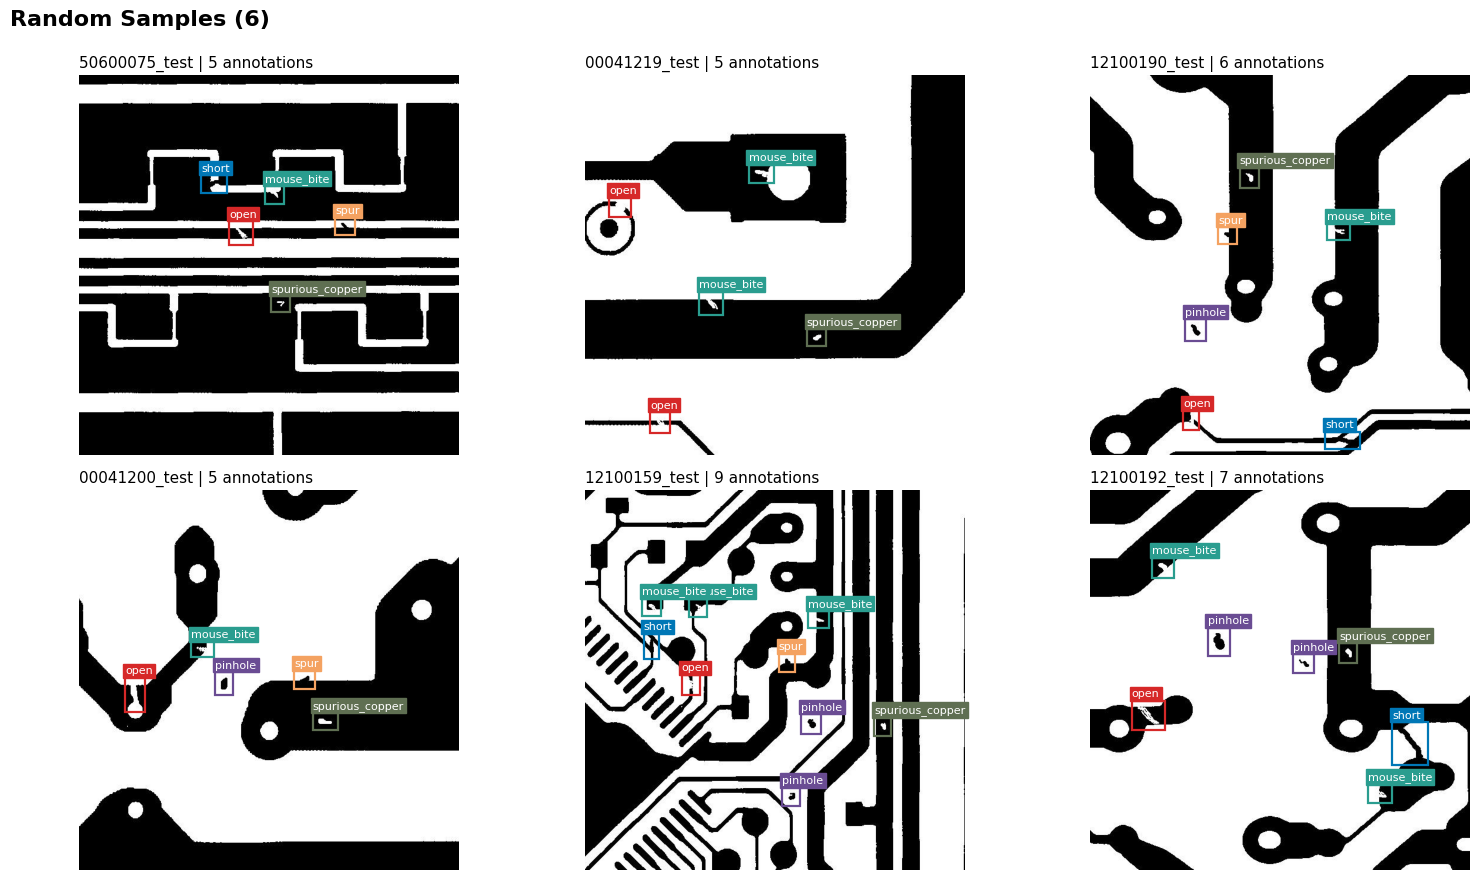

In [2]:
train_dataset = PCBDataset(train_config, "trainval.txt")
train_dataset.inspect()

test_dataset = PCBDataset(train_config, "test.txt")
test_dataset.inspect()

## Preprocessing Preview


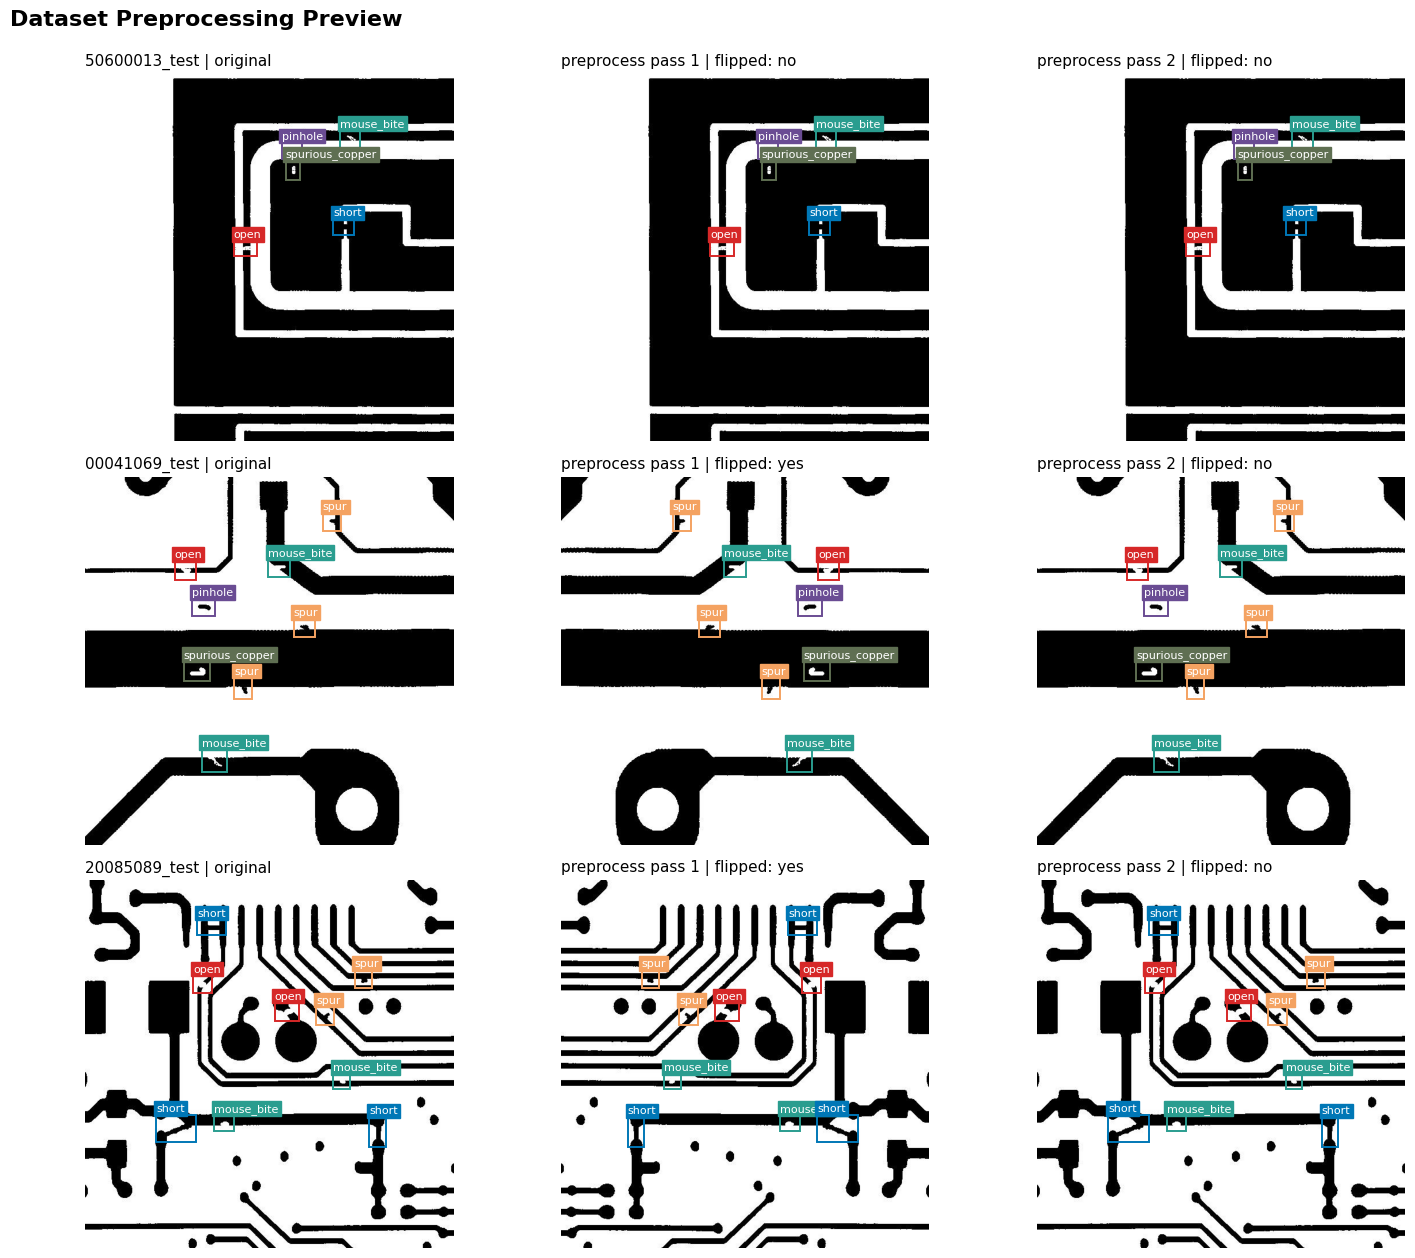

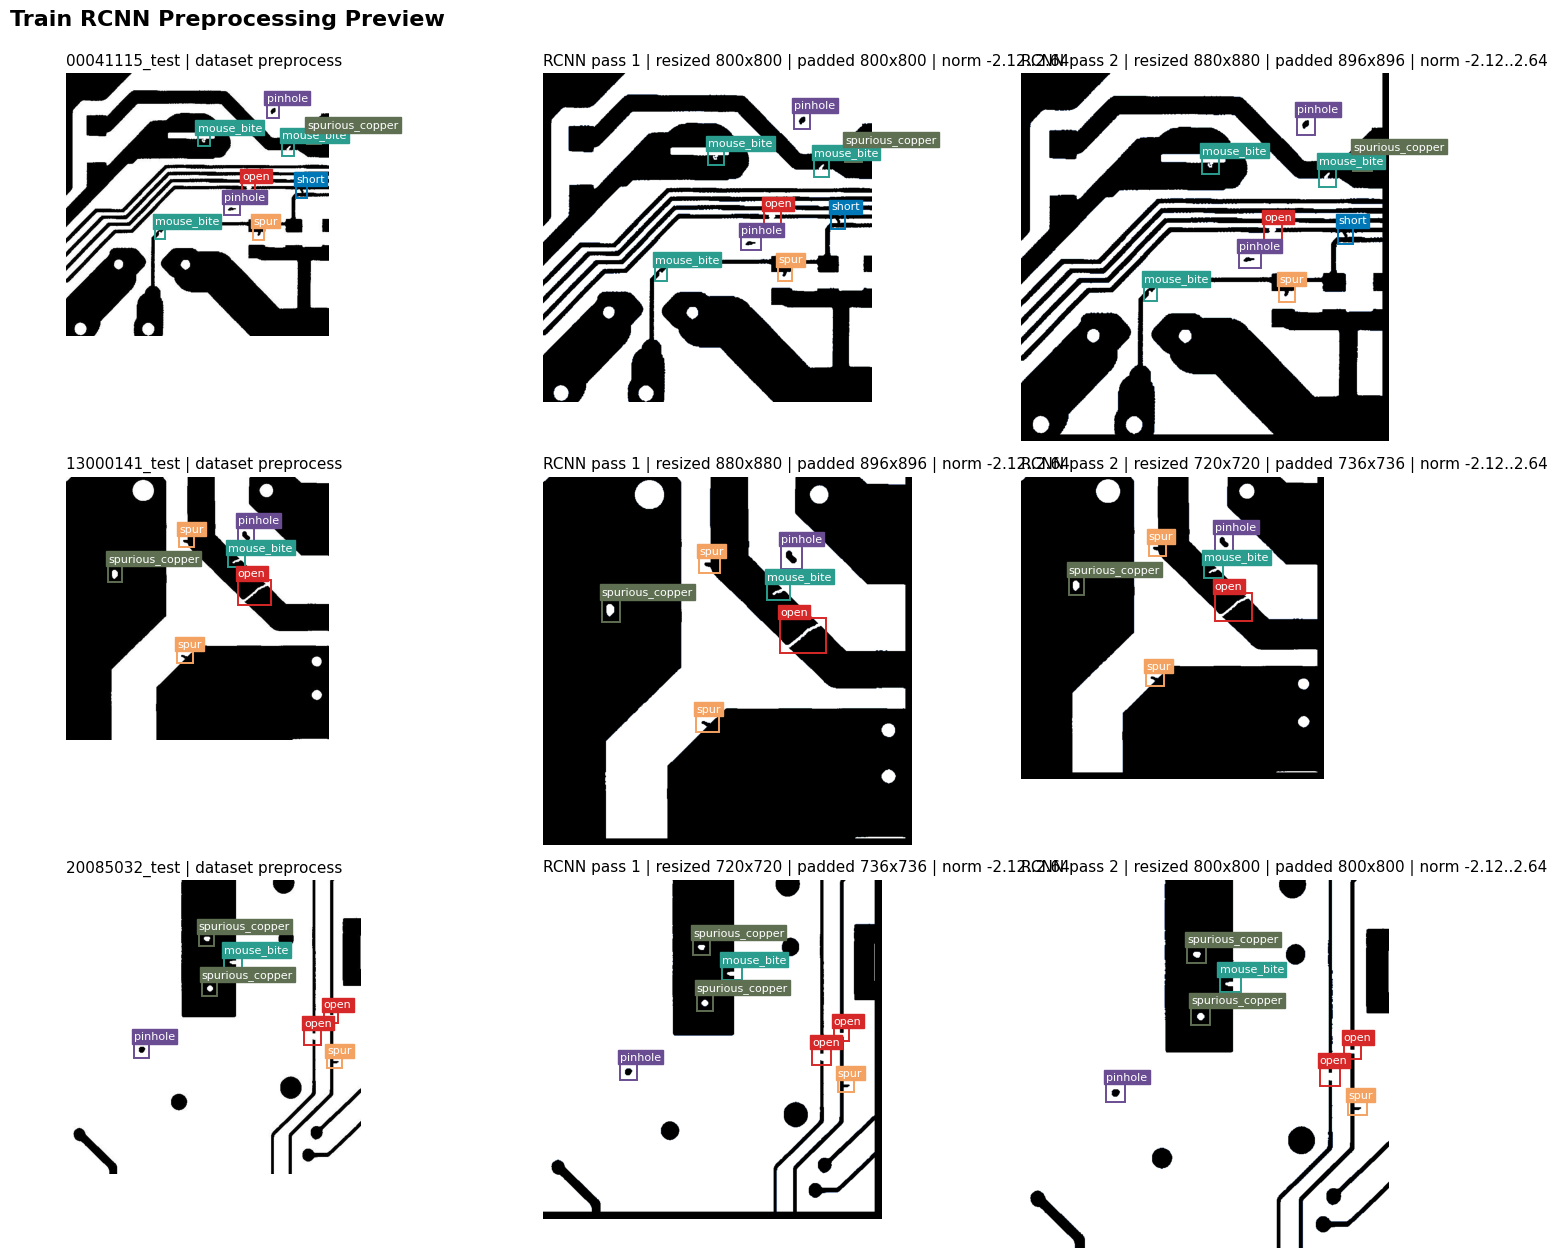

In [3]:
train_dataset.add_preprocess(
    train_preprocess(train_config["preprocessing"]["horizontal_flip_prob"])
)
test_dataset.add_preprocess(test_preprocess())

rcnn_preprocess = RCNNPreprocessing(train_config)

visualize_preprocessing(train_dataset)
visualize_rcnn_preprocessing(rcnn_preprocess, train_dataset)

## Model And Loaders


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=train_config["dataset"]["batch_size"],
    shuffle=True,
    num_workers=train_config["dataset"]["num_workers"],
    pin_memory=device.type == "cuda",
    collate_fn=detection_collate_fn,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=train_config["dataset"]["batch_size"],
    shuffle=False,
    num_workers=train_config["dataset"]["num_workers"],
    pin_memory=device.type == "cuda",
    collate_fn=detection_collate_fn,
)

model = NeuroFasterRCNN(
    neuro_config=neuro_config,
    train_config=train_config,
).to(device)

optimizer = SGD(
    [parameter for parameter in model.parameters() if parameter.requires_grad],
    lr=train_config["train"]["opt_lr"],
    momentum=train_config["train"]["opt_momentum"],
    weight_decay=train_config["train"]["opt_weight_decay"],
)

model.__class__.__name__, len(train_loader), len(test_loader)

('NeuroFasterRCNN', 1000, 500)

## Train


Starting Faster R-CNN training on cuda for 12 epochs (1000 batches per epoch).


Epoch 12/12: 100%|██████████| 1000/1000 [00:59<00:00, 16.93it/s, cls=0.0616, loss=0.2435, lr=2.00e-04, reg=0.1736, rpn=0.0014]


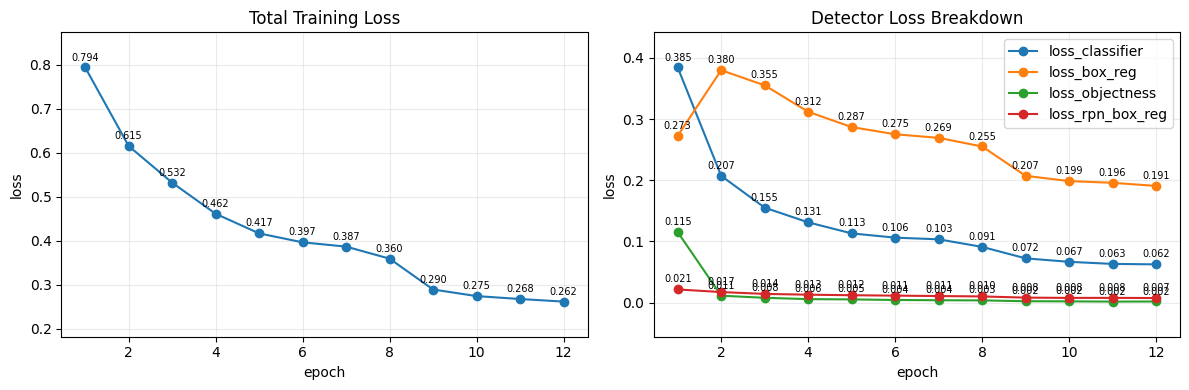

In [5]:
history = train_model(
    model=model,
    data_loader=train_loader,
    optimizer=optimizer,
    device=device,
    train_config=train_config,
)

history_frame = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_frame.plot(x="epoch", y="loss_total", marker="o", ax=axes[0], legend=False)
axes[0].set_title("Total Training Loss")
axes[0].set_ylabel("loss")
axes[0].grid(alpha=0.25)
axes[0].margins(y=0.15)
for epoch, loss in zip(history_frame["epoch"], history_frame["loss_total"]):
    axes[0].annotate(
        f"{loss:.3f}",
        (epoch, loss),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=7,
    )

loss_columns = [
    column
    for column in [
        "loss_classifier",
        "loss_box_reg",
        "loss_objectness",
        "loss_rpn_box_reg",
    ]
    if column in history_frame
]
history_frame.plot(x="epoch", y=loss_columns, marker="o", ax=axes[1])
axes[1].set_title("Detector Loss Breakdown")
axes[1].set_ylabel("loss")
axes[1].grid(alpha=0.25)
axes[1].margins(y=0.15)
for line in axes[1].lines:
    for epoch, loss in zip(line.get_xdata(), line.get_ydata()):
        axes[1].annotate(
            f"{loss:.3f}",
            (epoch, loss),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=7,
        )

plt.tight_layout()
plt.show()

## Final Evaluation


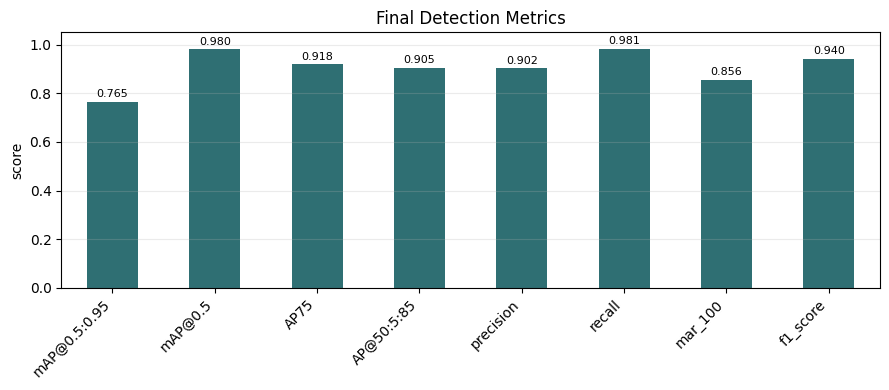

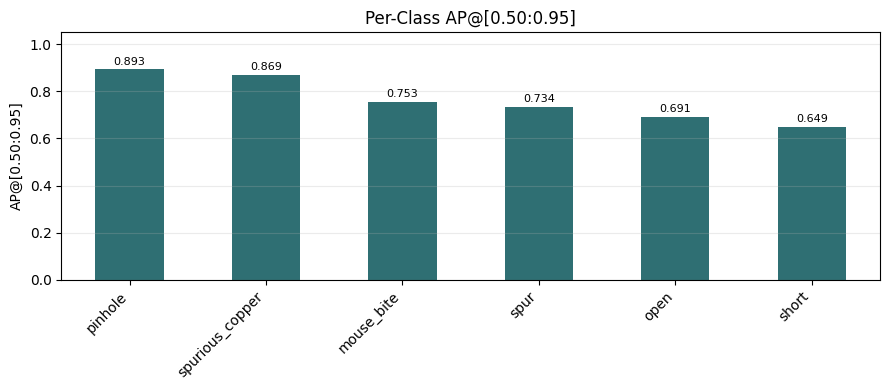

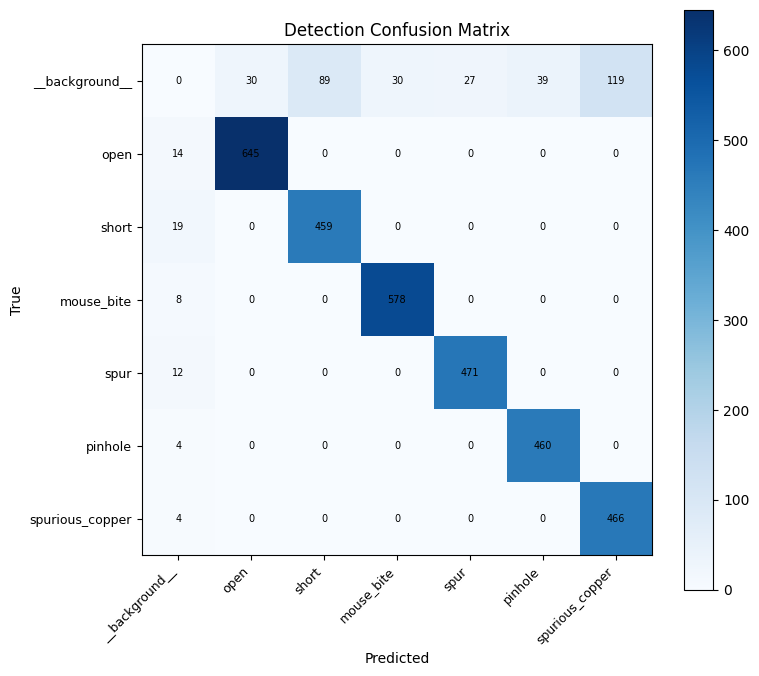

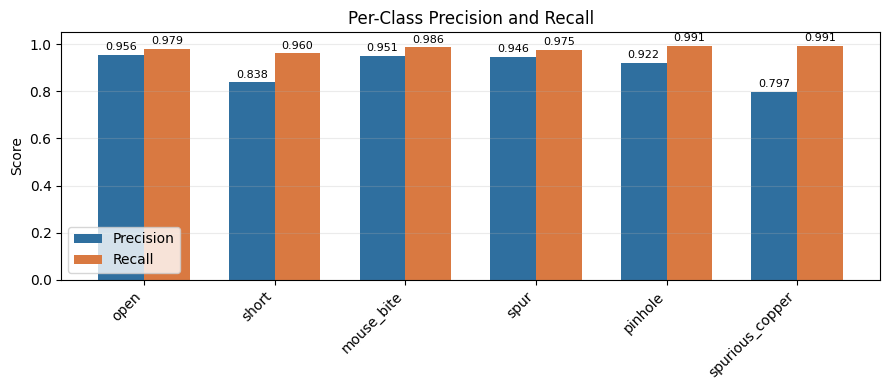

Efficiency:
  Inference time: 44.58 ms
  Parameters: 36,228,914


,mAP@0.5:0.95,mAP@0.5,AP75,AP@50:5:85,precision,recall,mar_100,f1_score
0,0.765063,0.980071,0.918392,0.905374,0.902139,0.980573,0.855684,0.939722


In [6]:
metrics = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    train_config=train_config,
)

skip_keys = {"precision_recall_score_threshold", "inference_time_ms", "parameter_count"}
metric_frame = pd.DataFrame(
    [
        {
            key: value
            for key, value in metrics.items()
            if isinstance(value, (int, float)) and key not in skip_keys
        }
    ]
)

ax = metric_frame.T.plot(
    kind="bar",
    legend=False,
    figsize=(9, 4),
    color="#2f6f73",
)
ax.set_title("Final Detection Metrics")
ax.set_ylabel("score")
ax.set_ylim(0.0, 1.05)
ax.grid(axis="y", alpha=0.25)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=2, fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if "per_class_AP" in metrics:
    per_class_frame = pd.Series(metrics["per_class_AP"], name="AP").sort_values(
        ascending=False
    )
    ax = per_class_frame.plot(kind="bar", figsize=(9, 4), color="#2f6f73")
    ax.set_title("Per-Class AP@[0.50:0.95]")
    ax.set_ylabel("AP@[0.50:0.95]")
    ax.set_ylim(0.0, 1.05)
    ax.grid(axis="y", alpha=0.25)
    ax.bar_label(ax.containers[0], fmt="%.3f", padding=2, fontsize=8)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if "confusion_matrix" in metrics:
    cm = np.array(metrics["confusion_matrix"])
    cm_labels = metrics["confusion_matrix_labels"]
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(cm_labels)))
    ax.set_yticks(range(len(cm_labels)))
    ax.set_xticklabels(cm_labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(cm_labels, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Detection Confusion Matrix")
    cm_max = cm.max()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > cm_max * 0.5 else "black"
            ax.text(
                j, i, str(cm[i, j]), ha="center", va="center", fontsize=7, color=color
            )
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

if "per_class_precision" in metrics:
    pr_labels = [k for k in metrics["per_class_precision"] if k != "__background__"]
    x = np.arange(len(pr_labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(
        x - width / 2,
        [metrics["per_class_precision"][c] for c in pr_labels],
        width,
        label="Precision",
        color="#2F6F9F",
    )
    ax.bar(
        x + width / 2,
        [metrics["per_class_recall"][c] for c in pr_labels],
        width,
        label="Recall",
        color="#D97941",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(pr_labels, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Per-Class Precision and Recall")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    ax.bar_label(ax.containers[0], fmt="%.3f", padding=2, fontsize=8)
    ax.bar_label(ax.containers[1], fmt="%.3f", padding=2, fontsize=8)
    plt.tight_layout()
    plt.show()
    print("Efficiency:")
    print(f"  Inference time: {metrics.get('inference_time_ms', 0):.2f} ms")
    print(f"  Parameters: {metrics.get('parameter_count', 0):,}")

metric_frame

## Save Run


In [7]:
artifacts = next_run_artifacts(Path("checkpoints") / "neuro")

checkpoint_payload = {
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "neuro_config": neuro_config,
    "train_config": train_config,
    "metrics": metrics,
    "history": history,
}

torch.save(checkpoint_payload, artifacts.checkpoint_path)
save_json(metrics, artifacts.metrics_path)
save_json(history, artifacts.history_path)

run_result = {
    "run_name": artifacts.run_name,
    "checkpoint_path": str(artifacts.checkpoint_path),
    "metrics_path": str(artifacts.metrics_path),
    "history_path": str(artifacts.history_path),
    "metrics": metrics,
    "history": history,
}
assert Path(run_result["checkpoint_path"]).exists()
assert Path(run_result["metrics_path"]).exists()
assert Path(run_result["history_path"]).exists()